# Implementing Language Models are Few-Shot Learners by `Brown et al 2020.`

## Table of Contents

1. [Motivation and Problem Statement](#1-motivation-and-problem-statement)
2. [Core Research Questions](#2-core-research-questions)
3. [Key Concepts and Terminology](#3-key-concepts-and-terminology)
4. [Model Architecture](#4-model-architecture)
5. [Training Data and Preprocessing](#5-training-data-and-preprocessing)
6. [Methodology: In-Context Learning](#6-methodology-in-context-learning)
7. [Mathematical Foundations](#7-mathematical-foundations)
8. [Experimental Setup and Evaluation](#8-experimental-setup-and-evaluation)
9. [Results and Key Findings](#9-results-and-key-findings)
10. [Comparison with Baseline Methods](#10-comparison-with-baseline-methods)
11. [Limitations and Challenges](#11-limitations-and-challenges)

## 1. Problem Statement

### The Problem with Traditional NLP

The standard approach to building NLP systems before GPT-3 followed stages first pre-training then fine tuning and finally building task specific model. In layman terms it will mean suppose you want to build a chatbot for a certain client. Your approach might be as follows:

1. **Pre-train**: Train a large language model on massive amounts of data according to your need (books, websites, articles).
2. **Collect Data**: Gather thousands of labeled examples of customer questions and correct answers.
3. **Fine-tune**: Retrain the model specifically on your customer data.
4. **Deploy**: Use the fine-tuned model.

But when we follow these standard methods there are certain problems such as:
* **Data Hungry**: We need thousands of labeled examples for each new task.
* **Expensive**: Labeling data requires human experts which can be costly and slow.
* **Task-Specific**: Each new task requires a new fine-tuning cycle.
* **Poor Generalization**  Models may not transfer knowledge well to new domains. 
* **Spurious Correlations**  Models might learn dataset specific shortcuts but not have true understanding.

### The Human Connection

When humans learn something they don't need thousands of examples to learn new task. If we are showing a child 3 examples of how a banana and how a mango visually appear they can likely identify one in the the supermarket pretty easily. But fine tuned models need hundreds or thousands of examples.

Therefore the authors answered one of the most important question in this paper i.e. **can we create a model that learns like humans from just a few examples or instructions?**


## 2. Core Research Questions

### Primary Research Question

The major question which this paper answers is that:
> **Can scaling language models to greater sizes unlock the ability to perform new tasks with minimal examples i.e. few shot or no examples at all i.e. zero-shot?**

### Secondary Questions

1. **How does task performance scale with model size?**
   - Do larger models learn more from fewer examples?
   
2. **What is "in-context learning" and how does it work?**
   - Can models learn from examples provided at inference time and without weight updates?
   
3. **What are the limits of few-shot learning?**
   - Which tasks benefit most? Which tasks still require fine-tuning?

## 3. Key Concepts and Terminology

### Understanding the "Shots" in Learning

The paper introduces a  of learning paradigms:

```
┌─────────────────────────────────────────────────────────────────┐
│                     LEARNING PARADIGMS                          │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  ┌───────────────┐                                              │
│  │  ZERO-SHOT    │  "No examples, just instructions"            │
│  │  Learning     │                                              │
│  │               │  Task: Translate English to French           │
│  │               │  Input: "Hello" → Output: "Bonjour"          │
│  └───────────────┘                                              │
│                                                                 │
│  ┌───────────────┐                                              │
│  │  ONE-SHOT     │  "Single example provided"                   │
│  │  Learning     │                                              │
│  │               │  Example: "Hello" = "Bonjour"                │
│  │               │  Input: "Goodbye" → Output: "Au revoir"      │
│  └───────────────┘                                              │
│                                                                 │
│  ┌───────────────┐                                              │
│  │  FEW-SHOT     │  "Multiple examples (typically 10-100)"      │
│  │  Learning     │                                              │
│  │               │  Examples:                                   │
│  │               │    "Hello" = "Bonjour"                       │
│  │               │    "Thank you" = "Merci"                     │
│  │               │    "Please" = "S'il vous plaît"              │
│  │               │  Input: "How are you?" → Output: ?           │
│  └───────────────┘                                              │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

### In-Context Learning

In-context learning is the ability of a language model when we learn from examples provided directly in the input prompt but without any gradient updates to the model's weights.

**Why is this different?**

In traditional machine learning we have training examples with weight updates and then finally model improves but in the **In-Context Learning** we give examples in the prompt itself which then model interprets and then it finally results in generating answers with no weight updates.

**Analogy**: Think of in-context learning like an open-book exam. The book (examples) is given to us during the test and then we use it to answer questions but we don't memorize it for later. We are totally relying on our logical skills to answer our tasks.

#### How In-Context Learning Works

1. **Pattern Matching:**

The model recognizes the pattern `"X" => "Y"` and applies it to every new input.

2. **Internal Fine-tuning:**

Some research suggests the Transformer layers implicitly perform gradient descent on the in-context examples.

3. **Skill Activation**

Pre-training develops latent skills and then the examples activate the relevant skill.


### Meta-learning

The paper says GPT-3 performs a form of **meta-learning** i.e. during pre-training the model develops a broad set of skills and pattern recognition abilities which inference time uses these abilities to rapidly adapt to the task demonstrated in the context.



## 4. Model Architecture

### Building on the Transformer

GPT-3's architecture is based on the **Transformer decoder**, which was introduced in the famous "Attention Is All You Need" paper (2017).

```
┌────────────────────────────────────────────────────────────────┐
│                    GPT-3 ARCHITECTURE                          │
│                                                                │
│                    ┌─────────────────┐                         │
│                    │    Output       │                         │
│                    │  Probabilities  │                         │
│                    └────────┬────────┘                         │
│                             │                                  │
│                    ┌────────▼────────┐                         │
│                    │   Softmax       │                         │
│                    └────────┬────────┘                         │
│                             │                                  │
│                    ┌────────▼────────┐                         │
│                    │  Linear Layer   │                         │
│                    └────────┬────────┘                         │
│                             │                                  │
│              ┌──────────────▼──────────────┐                   │
│              │                             │                   │
│              │   96 Transformer Layers     │ ◄── GPT-3 175B    │
│              │   (Decoder-only blocks)     │                   │
│              │                             │                   │
│              │   Each layer contains:      │                   │
│              │   • Multi-Head Attention    │                   │
│              │   • Feed-Forward Network    │                   │
│              │   • Layer Normalization     │                   │
│              │                             │                   │
│              └──────────────┬──────────────┘                   │
│                             │                                  │
│                    ┌────────▼────────┐                         │
│                    │   Positional    │                         │
│                    │   Encoding      │                         │
│                    └────────┬────────┘                         │
│                             │                                  │
│                    ┌────────▼────────┐                         │
│                    │    Token        │                         │
│                    │   Embeddings    │                         │
│                    └────────┬────────┘                         │
│                             │                                  │
│                    ┌────────▼────────┐                         │
│                    │ Input Tokens    │                         │
│                    └─────────────────┘                         │
│                                                                │
└────────────────────────────────────────────────────────────────┘
```

### Key Difference of GPT-3 Architecture:

In GPT-3 we use sparse attention transformer architecture. The standard transformers have a quadratic bottleneck. Suppose if the sequence length is $n$ then self attention cost is $O(n^2)$ but for GPT-3 we have context length of 2048 and layers and attention heads upto 96. Therefore this becomes extremely expensive in memory and compute.

> A sparse transformer is a transformer where each token attends to only a subset of other tokens but not all of them.

## Complete Implementation from Scratch

### What We'll Implement

1. **Self-Attention:** The core mechanism of GPT.
2. **Transformer Decoder Blocks:** Stacked layers with attention + MLP.
3. **Complete GPT Model:** Complete end-to-end language model.
4. **Training Pipeline:** Next-token prediction.
5. **Few-Shot Learning:** The paper's key innovation.
6. **Visualizations:** Attention patterns and scaling analysis.

#### 1. Importing Libraries

In [1]:
import math
import warnings
import numpy as np

In [2]:
import torch
print(torch.__version__)
print(torch.backends.mps.is_available())

/Users/adityamishra/pytorch-test/env/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


2.8.0
True


In [3]:
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [4]:
from dataclasses import dataclass
from typing import Optional, Tuple, List
from torch.utils.data import Dataset, DataLoader

In [5]:
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [6]:
@dataclass
class GPTConfig:
    vocab_size: int = 50257# size of vocabulary
    n_positions: int = 1024# maximum sequence length
    n_embd: int = 256   # embedding dimension
    n_layer: int = 6    # number of transformer blocks
    n_head: int = 8     # number of attention heads
    #training hyperparameters
    dropout: float = 0.1 # dropout rate
    bias: bool = True    # use bias in linear layers
    
    @property
    def head_dim(self) -> int:
        return self.n_embd // self.n_head# dimension of each attention head where n_embd is divisible by n_head
    

CONFIG_TINY = GPTConfig(n_embd=128, n_layer=4, n_head=4)       # ~3M params
CONFIG_SMALL = GPTConfig(n_embd=256, n_layer=6, n_head=8)      # ~10M params
CONFIG_MEDIUM = GPTConfig(n_embd=512, n_layer=8, n_head=8)     # ~40M params

print("GPT Configurations:")
print(f"Tiny: d_model={CONFIG_TINY.n_embd}, layers={CONFIG_TINY.n_layer}, heads={CONFIG_TINY.n_head}")
print(f"Small: d_model={CONFIG_SMALL.n_embd}, layers={CONFIG_SMALL.n_layer}, heads={CONFIG_SMALL.n_head}")
print(f"Medium: d_model={CONFIG_MEDIUM.n_embd}, layers={CONFIG_MEDIUM.n_layer}, heads={CONFIG_MEDIUM.n_head}")

GPT Configurations:
Tiny: d_model=128, layers=4, heads=4
Small: d_model=256, layers=6, heads=8
Medium: d_model=512, layers=8, heads=8


#### 2. Multi Head Self Attention



In [7]:
class SelfAttention(nn.Module):
    
    def __init__(self, config: GPTConfig):
        super().__init__()# Initialize the SelfAttention module
        assert config.n_embd % config.n_head == 0, "Embedding dimension must be divisible by number of heads"# Ensure embedding dimension is divisible by number of heads
        
        self.n_head = config.n_head# Number of attention heads
        self.head_dim = config.head_dim# Dimension of each attention head
        self.n_embd = config.n_embd# Embedding dimension
        self.dropout = nn.Dropout(config.dropout)# Dropout layer for regularizations
        
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)# Linear layer to compute queries, keys, and values
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)# Linear layer to project the output back to embedding dimension
        
        #regularisation
        self.attn_dropout = nn.Dropout(config.dropout)# Dropout layer for attention weights
        self.resid_dropout = nn.Dropout(config.dropout)# Dropout layer for residual connection
        """
        WHhen predicting next token, we want to prevent the model from attending to future tokens in the sequence. This is achieved by creating a causal mask, which is a lower triangular matrix that allows each position to attend only to itself and previous positions. The mask is registered as a buffer in the module, ensuring it is moved to the appropriate device (CPU or GPU) along with the model parameters.
        """
        self.register_buffer("bias",
            torch.tril(torch.ones(config.n_positions, config.n_positions))
            .view(1, 1, config.n_positions, config.n_positions)
        )# Register a buffer for the causal mask to prevent attending to future tokens
        
        
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass of causal self-attention.
        
        Args:
            x: Input tensor of shape (batch_size, seq_len, n_embd)
            
        Returns:
            output: Attended output of shape (batch_size, seq_len, n_embd)
            attn_weights: Attention weights for visualization
        """
        B, T, C = x.size()  # batch, sequence length, embedding dim

        # Calculate Q, K, V for all heads in batch
        qkv = self.c_attn(x)  # (B, T, 3*C)
        q, k, v = qkv.split(self.n_embd, dim=2)  # Each is (B, T, C)

        # Reshape for multi-head attention: (B, T, C) -> (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        # Compute attention scores
        attn = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.head_dim))

        # Apply causal mask: set future positions to -inf
        attn = attn.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))

        # Softmax to get attention probabilities
        attn_weights = F.softmax(attn, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        # Apply attention to values
        y = attn_weights @ v

        # Reshape back: (B, n_head, T, head_dim) -> (B, T, C)
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # Output projection
        y = self.resid_dropout(self.c_proj(y))

        return y, attn_weights

In [8]:
print("TESTING SELF ATTENTION MODULE")
config = CONFIG_TINY
attn = SelfAttention(config)
x = torch.randn(2, 10, config.n_embd)  # batch=2, seq_len=10
out, weights = attn(x)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {out.shape}")
print(f"Attn weights: {weights.shape}")
print("Attention mechanism SUCCESSFUL")

TESTING SELF ATTENTION MODULE
Input shape:  torch.Size([2, 10, 128])
Output shape: torch.Size([2, 10, 128])
Attn weights: torch.Size([2, 4, 10, 10])
Attention mechanism SUCCESSFUL


#### 3. Feed-Forward Network (MLP)

In [9]:
#building feed forward network for transformer block
class MLP(nn.Module):
    
    def __init__(self, config:GPTConfig):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias = config.bias)# First linear layer to expand the embedding dimension
        self.gelu = nn.GELU()# GELU activation function for non-linearity
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias = config.bias)# Second linear layer to project back to embedding dimension
        self.dropout = nn.Dropout(config.dropout)# Dropout layer for regularization
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
    # Forward pass of the MLP
        x = self.c_fc(x)  # Expand the embedding dimension
        x = self.gelu(x)  # Apply GELU activation
        x = self.c_proj(x)  # Project back to original embedding dimension
        x = self.dropout(x)  # Apply dropout for regularization
        return x
    

#### 4. Transformer Block

In [10]:
#Building a single transformer block to combine self attention and MLP with residual connections and layer normalization
class TransformerBlock(nn.Module):
    
    def __init__(self, config:GPTConfig):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)# Layer normalization before self-attention
        self.attn = SelfAttention(config)# Self-attention module
        self.ln_2 = nn.LayerNorm(config.n_embd)# Layer normalization before MLP
        self.mlp = MLP(config)# MLP module
        
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        #attention with residual connection
        attn_out, attn_weights = self.attn(self.ln_1(x))# Apply layer normalization and self-attention
        x = x + attn_out# Residual connection for attention output
        
        #MLP with residual connection
        x= x + self.mlp(self.ln_2(x))# Apply layer normalization and MLP, then add residual connection
        return x, attn_weights

print("built transformer block.")

built transformer block.


#### 5. Complete GPT Model

In [13]:
class GPT(nn.Module):
    
    def __init__(self, config: GPTConfig):
        
        super().__init__()# Initialize the GPT model
        self.config = config# Store the configuration
        
        #token and position embeddings
        self.wte = nn.Embedding(config.vocab_size, config.n_embd)# Token embedding layer
        self.wpe = nn.Embedding(config.n_positions, config.n_embd)# Position embedding layer
        self.drop = nn.Dropout(config.dropout)# Dropout layer for regularization
        
        #transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layer)])# Create a list of transformer blocks based on the number of layers specified in the configuration
        
        #final layer norm and output head
        self.ln_f = nn.LayerNorm(config.n_embd)# Final layer normalization before output
        
        #language modeling head
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)# Language modeling head to project hidden states to vocabulary size
        
        #weights initialization
        self.wte.weight = self.lm_head.weight# Tie the weights of the token embedding and language modeling head for better generalization
        self.apply(self._init_weights)# Apply custom weight initialization to all modules
        
        #counting parameters
        n_params = sum(p.numel() for p in self.parameters())
        print(f"Model initialized with {n_params/1e6:.2f} million parameters.")
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, input_ids: torch.Tensor,targets: Optional[torch.Tensor] = None
                ) -> Tuple[torch.Tensor, Optional[torch.Tensor], List[torch.Tensor]]:
        """
        Forward pass.
        
        Args:
            input_ids: Token indices (batch_size, seq_len)
            targets: Target tokens for loss computation (optional)
            
        Returns:
            logits: Predictions (batch_size, seq_len, vocab_size)
            loss: Cross-entropy loss if targets provided
            attention_weights: List of attention weights from each layer
        """
        B, T = input_ids.size()
        assert T <= self.config.n_positions, f"Sequence too long: {T} > {self.config.n_positions}"

        # Position indices
        pos = torch.arange(0, T, dtype=torch.long, device=input_ids.device)

        # Embeddings
        tok_emb = self.wte(input_ids)
        pos_emb = self.wpe(pos)
        x = self.drop(tok_emb + pos_emb)

        # Transformer blocks
        attention_weights = []
        for block in self.blocks:
            x, attn_w = block(x)
            attention_weights.append(attn_w)

        # Final layer norm and projection
        x = self.ln_f(x)
        logits = self.lm_head(x)

        # Compute loss if targets provided
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)

        return logits, loss, attention_weights

    @torch.no_grad()
    def generate(
        self,
        input_ids: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
    ) -> torch.Tensor:
        """
        Generate new tokens autoregressively.
        
        This is the core of text generation - predict one token at a time,
        then use that prediction as input for the next step.
        """
        self.eval()

        for _ in range(max_new_tokens):
            # Crop context if too long
            idx_cond = input_ids if input_ids.size(
                1) <= self.config.n_positions else input_ids[:, -self.config.n_positions:]

            # Get predictions
            logits, _, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            # Top-k filtering
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            # Sample
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            # Append
            input_ids = torch.cat([input_ids, next_token], dim=1)

        return input_ids

In [15]:
print("\nTesting GPT Model")
model = GPT(CONFIG_TINY).to(device)
# Test forward pass
test_input = torch.randint(0, CONFIG_TINY.vocab_size, (2, 20)).to(device)
test_target = torch.randint(0, CONFIG_TINY.vocab_size, (2, 20)).to(device)
logits, loss, attn = model(test_input, test_target)
print(f"Input shape:  {test_input.shape}")
print(f"Logits shape: {logits.shape}")
print(f"Loss: {loss.item():.4f}")
print("GPT model works.")


Testing GPT Model
Model initialized with 7.36 million parameters.
Input shape:  torch.Size([2, 20])
Logits shape: torch.Size([2, 20, 50257])
Loss: 10.9031
GPT model works.


#### 6. Tokenizer

In [17]:
#  character-level tokenizer instead of BPE for simplicity in this demonstration. In practice use a proper tokenizer.
class CharTokenizer:
    """
    Simple character-level tokenizer for demonstration.
    
    For production, use GPT-2 BPE tokenizer from 'transformers' library.
    """
    def __init__(self, text: str):
        chars = sorted(list(set(text)))
        self.char_to_idx = {ch: i for i, ch in enumerate(chars)}# Create a mapping from characters to indices
        self.idx_to_char = {i: ch for i, ch in enumerate(chars)}# Create a mapping from indices to characters
        self.vocab_size = len(chars)# Vocabulary size based on unique characters in the text

    def encode(self, text: str) -> List[int]:
        return [self.char_to_idx.get(ch, 0) for ch in text]# Encode a string into a list of character indices, using 0 for unknown characters

    def decode(self, indices: List[int]) -> str:
        return ''.join([self.idx_to_char.get(i, '') for i in indices])# Decode a list of character indices back into a string, ignoring unknown indices
print("CharTokenizer defined.")

CharTokenizer defined.


#### 7. Dataset for Language Modeling

In [18]:
class TextDataset(Dataset):
    """
    Dataset for language modeling.
    
    Creates sequences where the target is the input shifted by 1:
    Input:  [T, h, e, ' ', c]
    Target: [h, e, ' ', c, a]
    """
    def __init__(self, text: str, tokenizer, seq_length: int):
        self.tokenizer = tokenizer
        self.seq_length = seq_length
        self.tokens = tokenizer.encode(text)
        print(f"Dataset: {len(self.tokens)} tokens, {len(self)} sequences")

    def __len__(self):
        return max(0, len(self.tokens) - self.seq_length - 1)

    def __getitem__(self, idx):
        x = torch.tensor(
            self.tokens[idx:idx + self.seq_length], dtype=torch.long)
        y = torch.tensor(
            self.tokens[idx + 1:idx + self.seq_length + 1], dtype=torch.long)
        return x, y

In [19]:
# Sample training text
SAMPLE_TEXT = """
The quick brown fox jumps over the lazy dog. This is a simple sentence that demonstrates
language modeling. In language modeling, we train a neural network to predict the next
word or character given the previous context. GPT-3, introduced by OpenAI in 2020, is
a powerful language model with 175 billion parameters. It can perform many tasks without
fine-tuning, using only a few examples provided in the prompt. This is called few-shot
learning. The model learns patterns from vast amounts of text during pre-training, and
then applies this knowledge to new tasks at inference time. Machine learning has advanced
significantly in recent years. Deep learning models now power translation, summarization,
question answering, and many other applications. The Transformer architecture, introduced
in 2017, revolutionized natural language processing. Self-attention allows models to
capture long-range dependencies efficiently. GPT uses a decoder-only architecture with
causal attention, meaning each token can only attend to previous tokens. This makes it
naturally suited for text generation tasks. Artificial intelligence continues to evolve
at a rapid pace, with new models and techniques being developed constantly.
""" * 10  # Repeat for more training data

print(f"Training text length: {len(SAMPLE_TEXT)} characters")

Training text length: 12190 characters


#### 8. Training Loop

In [20]:
def train_model(model: GPT,train_dataset: TextDataset,epochs: int = 5,
    batch_size: int = 32,learning_rate: float = 3e-4,log_interval: int = 50):
    """
    Train the GPT model.
    
    Uses AdamW optimizer with gradient clipping.
    """
    model.train()

    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=learning_rate, weight_decay=0.1)

    losses = []
    step = 0

    print(f"\nTraining for {epochs} epochs...")

    for epoch in range(epochs):
        epoch_loss = 0

        for batch_idx, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)

            # Forward
            logits, loss, _ = model(x, y)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            losses.append(loss.item())
            epoch_loss += loss.item()
            step += 1

            if step % log_interval == 0:
                avg_loss = sum(losses[-log_interval:]) / log_interval
                print(f"Step {step:4d} | Loss: {avg_loss:.4f}")

        print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {epoch_loss/len(dataloader):.4f}")

    return losses

In [21]:
# Create tokenizer and dataset
tokenizer = CharTokenizer(SAMPLE_TEXT)

# Create model with correct vocab size
config = GPTConfig(
    vocab_size=tokenizer.vocab_size + 1,
    n_positions=128,
    n_embd=128,
    n_layer=4,
    n_head=4
)

print( f"\nConfig: vocab={config.vocab_size}, embd={config.n_embd}, layers={config.n_layer}")

model = GPT(config).to(device)
dataset = TextDataset(SAMPLE_TEXT, tokenizer, seq_length=64)


Config: vocab=47, embd=128, layers=4
Model initialized with 0.82 million parameters.
Dataset: 12190 tokens, 12125 sequences


In [22]:
# Train the model!
losses = train_model(model=model,train_dataset=dataset,epochs=5,
    batch_size=16, learning_rate=3e-4, log_interval=20)


Training for 5 epochs...
Step   20 | Loss: 3.2659
Step   40 | Loss: 2.8442
Step   60 | Loss: 2.6431
Step   80 | Loss: 2.5317
Step  100 | Loss: 2.4433
Step  120 | Loss: 2.3799
Step  140 | Loss: 2.3116
Step  160 | Loss: 2.2232
Step  180 | Loss: 2.1632
Step  200 | Loss: 2.0985
Step  220 | Loss: 2.0298
Step  240 | Loss: 1.9647
Step  260 | Loss: 1.8877
Step  280 | Loss: 1.8045
Step  300 | Loss: 1.7305
Step  320 | Loss: 1.6778
Step  340 | Loss: 1.5987
Step  360 | Loss: 1.5485
Step  380 | Loss: 1.4472
Step  400 | Loss: 1.4008
Step  420 | Loss: 1.3322
Step  440 | Loss: 1.2788
Step  460 | Loss: 1.2034
Step  480 | Loss: 1.1435
Step  500 | Loss: 1.0733
Step  520 | Loss: 1.0066
Step  540 | Loss: 0.9554
Step  560 | Loss: 0.8861
Step  580 | Loss: 0.8397
Step  600 | Loss: 0.7962
Step  620 | Loss: 0.7355
Step  640 | Loss: 0.7146
Step  660 | Loss: 0.6800
Step  680 | Loss: 0.6275
Step  700 | Loss: 0.6015
Step  720 | Loss: 0.5839
Step  740 | Loss: 0.5350
Epoch 1/5 | Avg Loss: 1.5158
Step  760 | Loss: 0.

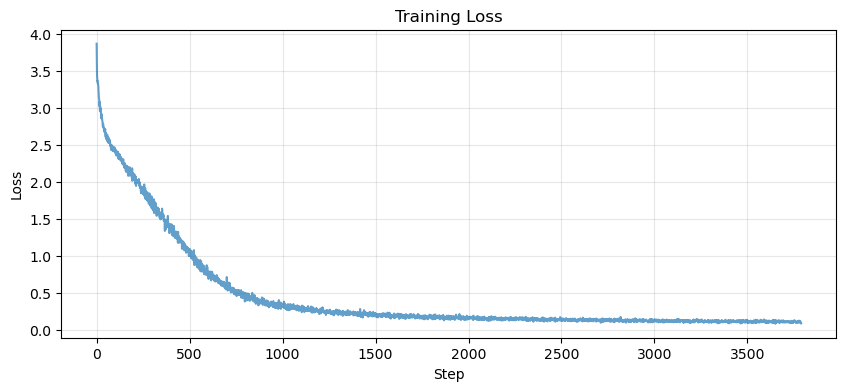

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.7)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()